In [1]:
import pandas as pd
import numpy as np


In [2]:
# Load your scored CSV
df = pd.read_csv(r'C:\Box\Box\BOX Subhashree Singh\Business\PAS\physician_scores_20260429_141959.csv', low_memory=False)
df = df.rename(columns={'composite_score': 'PAS_COMPOSITE_SCORE'})
print(f"Loaded {len(df)} physicians")
print(f"Columns: {df.columns.tolist()}")

Loaded 165623 physicians
Columns: ['NPI', 'COVEFF_DATE', 'OL_RISK_SPECIALTY_DESC', 'ST', 'WRTN_PREM_AMT_ITD_BURNED', 'kpi_actual_loss_ratio', 'kpi_expense_loss_cost', 'kpi_indemnity_frequency', 'kpi_indemnity_loss_cost', 'kpi_limits_to_premium', 'kpi_loss_free_years', 'kpi_total_frequency', 'kpi_total_loss_cost', 'kpi_total_severity', 'score_actual_loss_ratio', 'score_expense_loss_cost', 'score_income_inequality', 'score_indemnity_frequency', 'score_indemnity_loss_cost', 'score_limits_to_premium', 'score_loss_free_years', 'score_pct_uninsured', 'score_population_density', 'score_practice_size', 'score_risk_count', 'score_rvu_ratio', 'score_specialty_risk_tier', 'score_state_venue_risk', 'score_tenure_with_carrier', 'score_total_frequency', 'score_total_loss_cost', 'score_total_severity', 'score_violent_crime_rate', 'score_years_since_graduation', 'credibility_z', 'adequacy_score', 'capacity_score', 'appetite_score', 'environment_score', 'composite_score_raw', 'PAS_COMPOSITE_SCORE']


In [3]:
# for i in df.columns:
#     print(i)

In [4]:
# Basic stats on the composite score
print("=" * 60)
print("PAS COMPOSITE SCORE — SUMMARY STATISTICS")
print("=" * 60)
print(f"Mean:             {df['PAS_COMPOSITE_SCORE'].mean():.3f}")
print(f"Median:           {df['PAS_COMPOSITE_SCORE'].median():.3f}")
print(f"Std Dev:          {df['PAS_COMPOSITE_SCORE'].std():.3f}")
print(f"Min:              {df['PAS_COMPOSITE_SCORE'].min():.1f}")
print(f"Max:              {df['PAS_COMPOSITE_SCORE'].max():.1f}")
print(f"Total physicians: {len(df)}")

PAS COMPOSITE SCORE — SUMMARY STATISTICS
Mean:             4.483
Median:           4.000
Std Dev:          1.027
Min:              2.0
Max:              8.0
Total physicians: 165623


In [5]:
# How many physicians in each score band?
print("\n" + "=" * 60)
print("DISTRIBUTION BY BAND (Count)")
print("=" * 60)
value_counts = df['PAS_COMPOSITE_SCORE'].value_counts().sort_index()
print(value_counts)


DISTRIBUTION BY BAND (Count)
PAS_COMPOSITE_SCORE
2     1819
3    27712
4    55061
5    53793
6    24150
7     3085
8        3
Name: count, dtype: int64


In [6]:
# Same as percentage
print("\n" + "=" * 60)
print("DISTRIBUTION BY BAND (Percentage)")
print("=" * 60)
pct = (df['PAS_COMPOSITE_SCORE'].value_counts(normalize=True).sort_index() * 100).round(2)
print(pct)
print(f"\nTotal: {pct.sum():.1f}%")


DISTRIBUTION BY BAND (Percentage)
PAS_COMPOSITE_SCORE
2     1.10
3    16.73
4    33.24
5    32.48
6    14.58
7     1.86
8     0.00
Name: proportion, dtype: float64

Total: 100.0%


In [7]:
# Quartile breakdown
print("\n" + "=" * 60)
print("QUARTILE BREAKDOWN")
print("=" * 60)
q = df['PAS_COMPOSITE_SCORE'].quantile([0.25, 0.5, 0.75])
print(q)

# What percentage sit in the middle bands (4-5)?
middle = df[(df['PAS_COMPOSITE_SCORE'] >= 4) & (df['PAS_COMPOSITE_SCORE'] <= 5)].shape[0]
pct_middle = (middle / len(df)) * 100
print(f"\n% in bands 4-5: {pct_middle:.1f}%")


QUARTILE BREAKDOWN
0.25    4.0
0.50    4.0
0.75    5.0
Name: PAS_COMPOSITE_SCORE, dtype: float64

% in bands 4-5: 65.7%


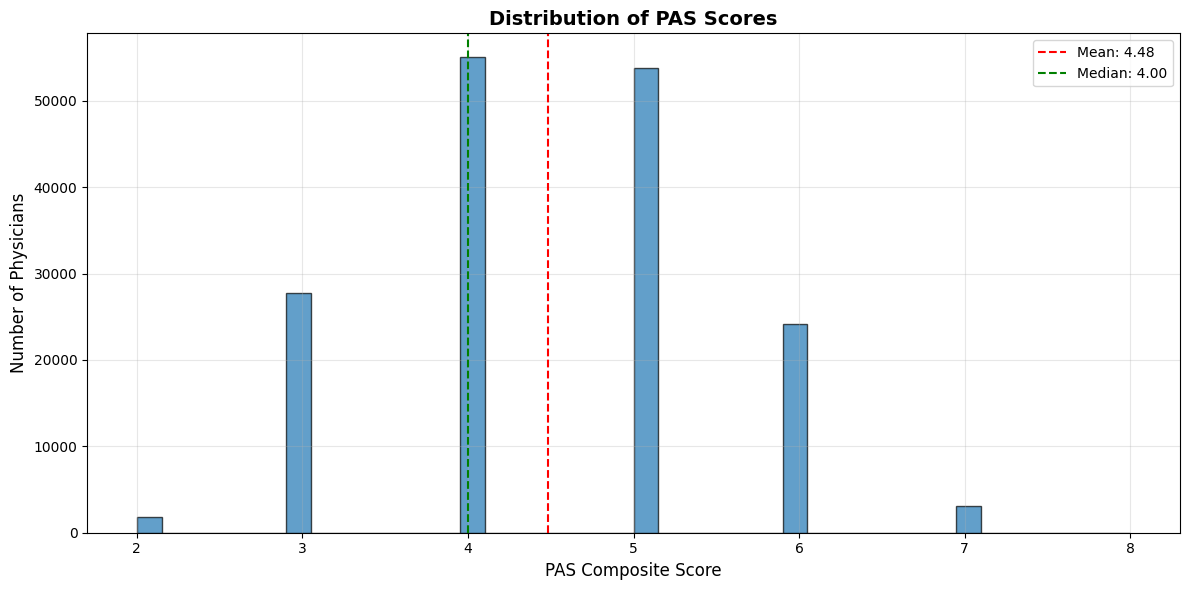

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
df['PAS_COMPOSITE_SCORE'].hist(bins=40, edgecolor='black', alpha=0.7)
plt.xlabel('PAS Composite Score', fontsize=12)
plt.ylabel('Number of Physicians', fontsize=12)
plt.title('Distribution of PAS Scores', fontsize=14, fontweight='bold')
plt.axvline(df['PAS_COMPOSITE_SCORE'].mean(), color='red', linestyle='--', label=f"Mean: {df['PAS_COMPOSITE_SCORE'].mean():.2f}")
plt.axvline(df['PAS_COMPOSITE_SCORE'].median(), color='green', linestyle='--', label=f"Median: {df['PAS_COMPOSITE_SCORE'].median():.2f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
print("=" * 60)
print("KEY STATISTICS")
print("=" * 60)
print(f"Mean:             {df['PAS_COMPOSITE_SCORE'].mean():.3f}")
print(f"Median:           {df['PAS_COMPOSITE_SCORE'].median():.3f}")
print(f"Std Dev:          {df['PAS_COMPOSITE_SCORE'].std():.3f}")
print(f"Min:              {df['PAS_COMPOSITE_SCORE'].min():.1f}")
print(f"Max:              {df['PAS_COMPOSITE_SCORE'].max():.1f}")

KEY STATISTICS
Mean:             4.483
Median:           4.000
Std Dev:          1.027
Min:              2.0
Max:              8.0


In [10]:
middle = df[(df['PAS_COMPOSITE_SCORE'] >= 4) & (df['PAS_COMPOSITE_SCORE'] <= 5)].shape[0]
pct_middle = (middle / len(df)) * 100
print(f"% in bands 4-5: {pct_middle:.1f}%")
print(f"Expected (synthetic pathology): 89%")
print(f"Your actual: {pct_middle:.1f}%")

% in bands 4-5: 65.7%
Expected (synthetic pathology): 89%
Your actual: 65.7%


In [12]:
print("=" * 60)
print("STANDARD DEVIATION")
print("=" * 60)
std_dev = df['PAS_COMPOSITE_SCORE'].std()
print(f"Your Std Dev:           {std_dev:.3f}")
print()
print("Comparison:")
print(f"  Synthetic pathology:    0.68  (collapsed, can't differentiate)")
print(f"  Healthy distribution:   ~2.0–2.5+")
print()
if std_dev > 2.0:
    print("✅ PASS — Model differentiates the book")
elif std_dev > 1.5:
    print("⚠️  CAUTION — Some differentiation but tighter than ideal")
else:
    print("❌ FAIL — Score lacks spread")

STANDARD DEVIATION
Your Std Dev:           1.027

Comparison:
  Synthetic pathology:    0.68  (collapsed, can't differentiate)
  Healthy distribution:   ~2.0–2.5+

❌ FAIL — Score lacks spread
